# 🎮 Games Analytics Project
## Notebook 01 — Retention Curve Analysis

**Analyst:** Manny Mologe  
**Dataset:** Synthetic mobile RPG dataset (calibrated to GameAnalytics benchmarks)  
**Objective:** Compute D1 / D7 / D30 retention by install cohort, acquisition channel, and platform. Compare against industry benchmarks and surface UA channel efficiency insights.

---
### Business Question
> Which install cohorts and acquisition channels produce the stickiest players,  
> and are our retention rates competitive against mobile RPG benchmarks?

## 1. Setup & Imports

In [ ]:
pip install pandas numpy matplotlib seaborn nbformat

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('/Users/ebimol/GamesAnalyticsProject')
OUT_DIR  = DATA_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi']    = 150
plt.rcParams['figure.figsize'] = (12, 5)
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
sns.set_theme(style='whitegrid', palette=PALETTE)
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load Data

In [2]:
players = pd.read_csv(DATA_DIR / 'players.csv',        parse_dates=['install_date', 'last_active_date'])
daily   = pd.read_csv(DATA_DIR / 'daily_activity.csv', parse_dates=['date'])

print(f'players shape  : {players.shape}')
print(f'daily   shape  : {daily.shape}')
display(players.head(3))
display(daily.head(3))

players shape  : (30000, 22)
daily   shape  : (208310, 12)


,player_id,install_date,platform,country,acquisition_channel,is_payer,total_iap_usd,last_active_date,days_active,total_sessions,...,total_matches_played,total_wins,win_rate,currency_earned_total,currency_spent_total,gems_earned_total,gems_spent_total,characters_owned,promoted_characters,legendary_count
0,P0000001,2026-04-07,iOS,IN,Google UAC,False,0.0,2026-04-08,2,3,...,4,2,0.5000,232,134,5,0,3,0,0
1,P0000002,2026-03-22,Android,IN,Google UAC,False,0.0,2026-06-08,7,21,...,44,16,0.3636,1639,1107,11,347,3,0,0
2,P0000003,2026-04-20,Android,BR,Google UAC,False,0.0,2026-05-05,8,25,...,38,10,0.2632,1865,1292,16,0,3,0,0


,player_id,date,day_since_install,sessions,playtime_min,matches_played,wins,currency_earned,currency_spent,gems_earned,gems_spent,iap_usd
0,P0000001,2026-04-07,0,1,2.59,3,2,98,31,5,0,0.0
1,P0000001,2026-04-08,1,2,7.16,1,0,134,103,0,0,0.0
2,P0000002,2026-03-22,0,6,30.16,12,3,480,445,0,344,0.0


## 3. Data Quality Checks

In [3]:
print('=== PLAYERS nulls ===')
print(players.isnull().sum()[players.isnull().sum() > 0])
print('\n=== DAILY nulls ===')
print(daily.isnull().sum()[daily.isnull().sum() > 0])

assert players['player_id'].nunique() == len(players), 'Duplicate player_ids found!'
print('\nNo duplicate player_ids ✓')
print(f'Install date range: {players.install_date.min().date()} → {players.install_date.max().date()}')
print(f'Daily date range  : {daily.date.min().date()} → {daily.date.max().date()}')

=== PLAYERS nulls ===
Series([], dtype: int64)

=== DAILY nulls ===
Series([], dtype: int64)

No duplicate player_ids ✓
Install date range: 2026-03-10 → 2026-07-07
Daily date range  : 2026-03-10 → 2026-07-08


## 4. Feature Engineering — Retention Flags

**Methodology:** A player is retained on Day N if they have at least one record  
in `daily_activity` where `day_since_install == N`.

**Eligibility windowing (critical):** I only include a player in the D7 denominator  
if they installed ≥7 days before the reference date. Without this, recently-installed  
players who haven't *had* 7 days yet would incorrectly drag down the retention rate —  
a classic cohort analysis mistake.  

The reference date is the maximum observed activity date in the dataset.

In [4]:
# Build lookup: player_id -> set of active days
active_days = (
    daily
    .groupby('player_id')['day_since_install']
    .apply(set)
    .to_dict()
)

def was_active_on(player_id: str, day: int) -> bool:
    return day in active_days.get(player_id, set())

players['D1']  = players['player_id'].map(lambda p: was_active_on(p, 1))
players['D7']  = players['player_id'].map(lambda p: was_active_on(p, 7))
players['D30'] = players['player_id'].map(lambda p: was_active_on(p, 30))

MAX_DATE = daily['date'].max()
print(f'Reference date: {MAX_DATE.date()}')

players['days_since_install'] = (MAX_DATE - players['install_date']).dt.days
elig1  = players['days_since_install'] >= 1
elig7  = players['days_since_install'] >= 7
elig30 = players['days_since_install'] >= 30

print(f'Eligible for D1  : {elig1.sum():,} players')
print(f'Eligible for D7  : {elig7.sum():,} players')
print(f'Eligible for D30 : {elig30.sum():,} players')

Reference date: 2026-07-08
Eligible for D1  : 30,000 players
Eligible for D7  : 28,658 players
Eligible for D30 : 23,388 players


## 5. Overall Retention vs Industry Benchmarks

Benchmark source: GameAnalytics Mobile RPG mid-performing segment.  
- D1: 35–45%  
- D7: 15–20%  
- D30: 5–8%

,Day,Retention Rate,Eligible N,Benchmark Low,Benchmark High,vs Benchmark
0,D1,42.9%,30000,35%,45%,✅ Within
1,D7,18.8%,28658,15%,20%,✅ Within
2,D30,8.0%,23388,5%,8%,✅ Within


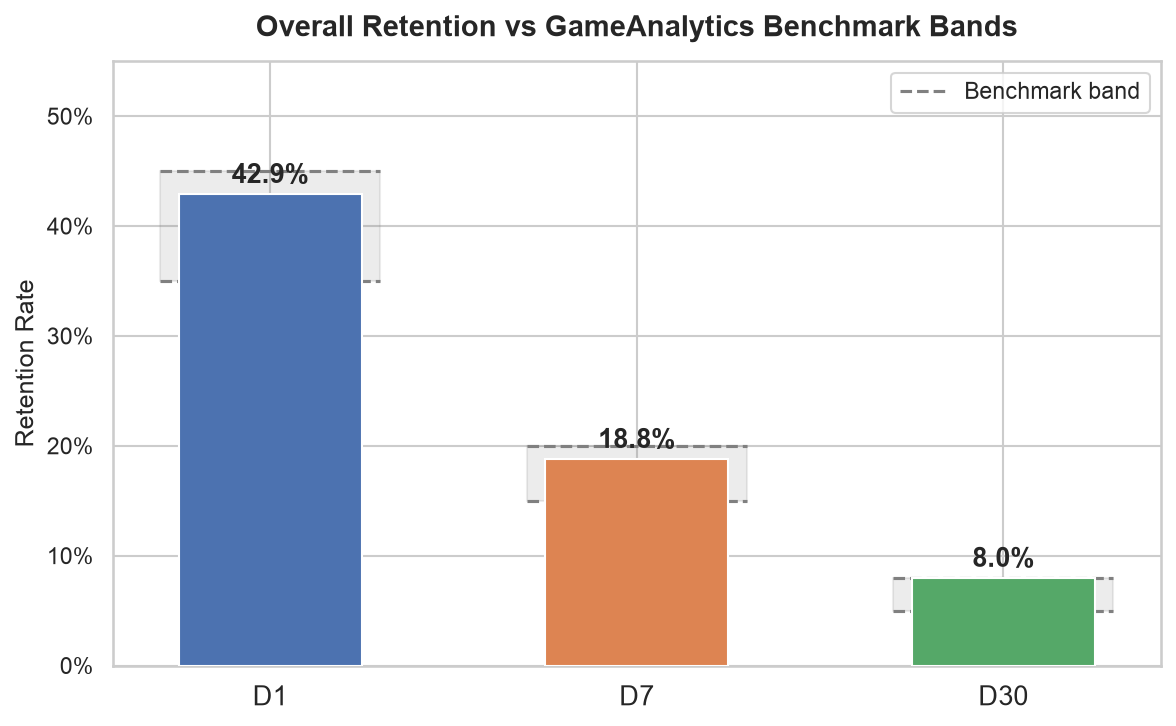

Chart saved ✓


In [5]:
ret_d1  = players.loc[elig1,  'D1'].mean()
ret_d7  = players.loc[elig7,  'D7'].mean()
ret_d30 = players.loc[elig30, 'D30'].mean()

overview = pd.DataFrame({
    'Day'            : ['D1', 'D7', 'D30'],
    'Retention Rate' : [ret_d1, ret_d7, ret_d30],
    'Eligible N'     : [elig1.sum(), elig7.sum(), elig30.sum()],
    'Benchmark Low'  : [0.35, 0.15, 0.05],
    'Benchmark High' : [0.45, 0.20, 0.08],
})
overview['vs Benchmark'] = overview.apply(
    lambda r: '✅ Within' if r['Benchmark Low'] <= r['Retention Rate'] <= r['Benchmark High']
              else ('⬆ Above' if r['Retention Rate'] > r['Benchmark High'] else '⬇ Below'),
    axis=1
)
display(overview.assign(**{
    'Retention Rate': overview['Retention Rate'].map('{:.1%}'.format),
    'Benchmark Low' : overview['Benchmark Low'].map('{:.0%}'.format),
    'Benchmark High': overview['Benchmark High'].map('{:.0%}'.format),
}))

# Bar chart with benchmark bands
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
bars = ax.bar(x, [ret_d1, ret_d7, ret_d30], color=PALETTE[:3], width=0.5, zorder=3)

for i, (lo, hi) in enumerate([(0.35, 0.45), (0.15, 0.20), (0.05, 0.08)]):
    ax.hlines(lo, i-0.3, i+0.3, colors='grey', linestyles='--', lw=1.5,
              label='Benchmark band' if i == 0 else '_nolegend_')
    ax.hlines(hi, i-0.3, i+0.3, colors='grey', linestyles='--', lw=1.5, label='_nolegend_')
    ax.fill_between([i-0.3, i+0.3], lo, hi, color='grey', alpha=0.15)

for bar, val in zip(bars, [ret_d1, ret_d7, ret_d30]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.1%}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['D1', 'D7', 'D30'], fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel('Retention Rate', fontsize=12)
ax.set_title('Overall Retention vs GameAnalytics Benchmark Bands', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.savefig(OUT_DIR / '01_retention_overall.png', dpi=150)
plt.show()
print('Chart saved ✓')

## 6. Cohort Helper Function

In [7]:
def cohort_retention(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Compute eligibility-windowed D1/D7/D30 retention for each unique value of group_col."""
    rows = []
    for g, sub in df.groupby(group_col):
        e1  = sub['days_since_install'] >= 1
        e7  = sub['days_since_install'] >= 7
        e30 = sub['days_since_install'] >= 30
        rows.append({
            group_col   : g,
            'n_players'  : len(sub),
            'D1'        : sub.loc[e1,  'D1']. mean() if e1.sum()  > 0 else np.nan,
            'D1_n'      : int(e1.sum()),
            'D7'        : sub.loc[e7,  'D7']. mean() if e7.sum()  > 0 else np.nan,
            'D7_n'      : int(e7.sum()),
            'D30'       : sub.loc[e30, 'D30'].mean() if e30.sum() > 0 else np.nan,
            'D30_n'     : int(e30.sum()),
        })
    return pd.DataFrame(rows)

print('cohort_retention() defined ✓')

cohort_retention() defined ✓


## 7. Retention Curves by Install Cohort Week

Grouping installs by calendar week lets us detect whether product changes or  
UA campaigns are shifting early retention up or down over time.

18 weekly cohorts


,install_week,n_players,D1,D7,D30
0,2026-03-09 00:00:00,1376,44.5%,20.1%,8.4%
1,2026-03-16 00:00:00,1825,43.0%,18.4%,8.2%
2,2026-03-23 00:00:00,2201,41.8%,18.6%,8.5%
3,2026-03-30 00:00:00,1773,41.2%,20.1%,7.8%
4,2026-04-06 00:00:00,1602,44.7%,19.3%,8.4%


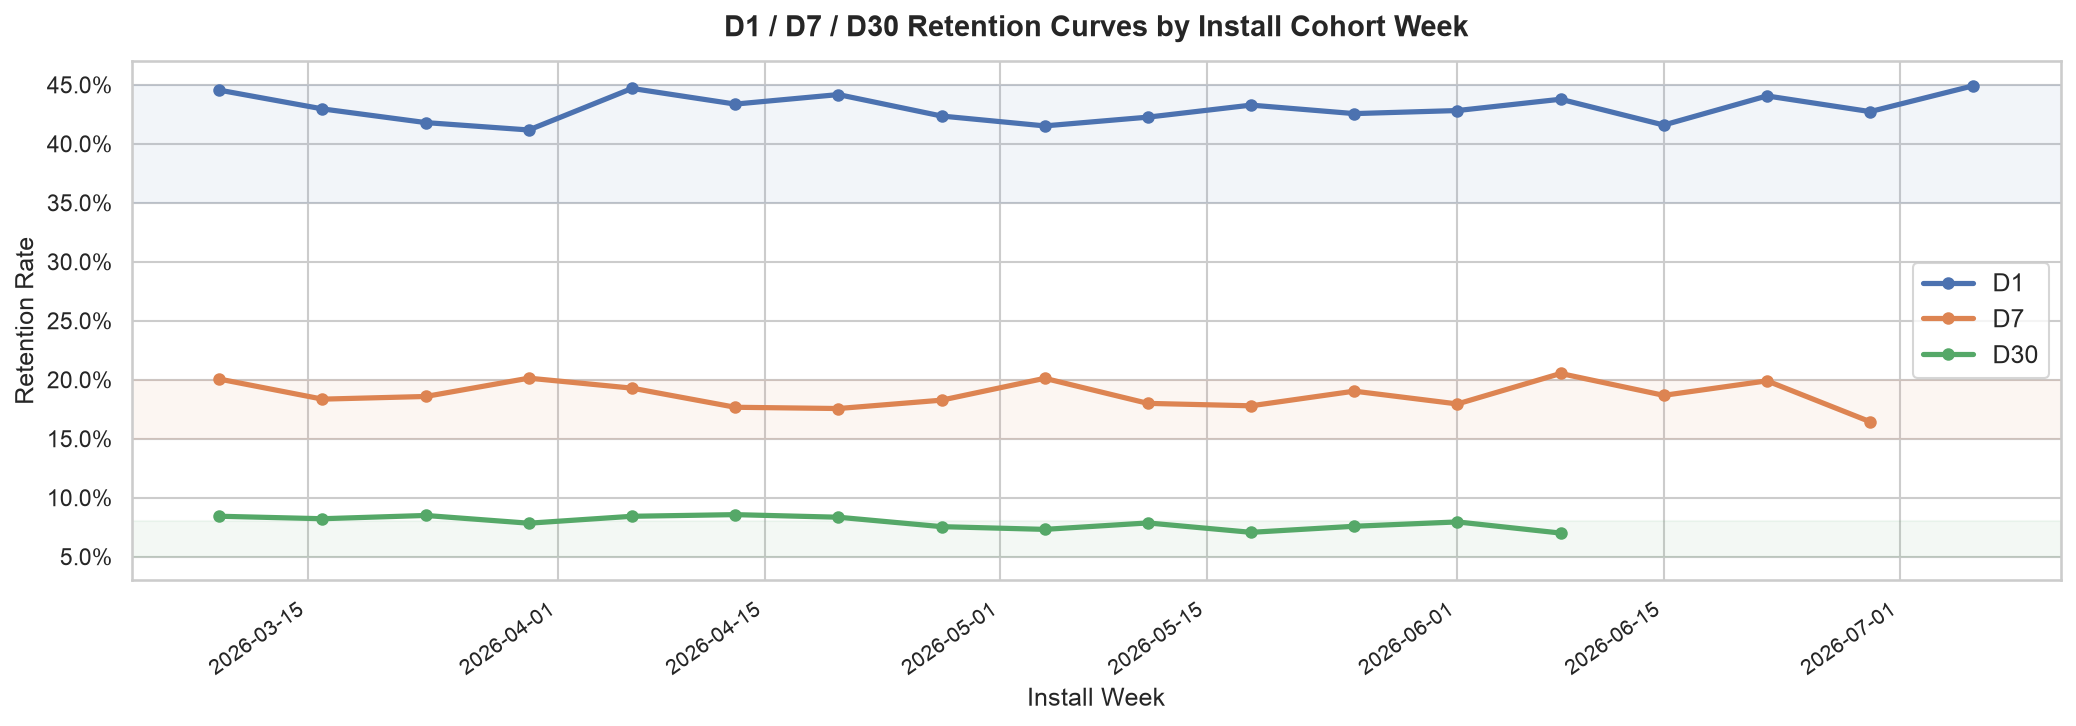

Chart saved ✓


In [8]:
players['install_week'] = players['install_date'].dt.to_period('W').apply(lambda r: r.start_time)

cohort_week = cohort_retention(players, 'install_week').sort_values('install_week')
print(f'{len(cohort_week)} weekly cohorts')
display(cohort_week[['install_week','n_players','D1','D7','D30']].head(5)
        .style.format({'D1':'{:.1%}','D7':'{:.1%}','D30':'{:.1%}'}))

fig, ax = plt.subplots(figsize=(14, 5))
for col, color in zip(['D1', 'D7', 'D30'], PALETTE[:3]):
    valid = cohort_week.dropna(subset=[col])
    ax.plot(valid['install_week'], valid[col], marker='o', ms=5, lw=2.5, label=col, color=color)

# Shaded benchmark bands
for lo, hi, c in zip([0.35, 0.15, 0.05], [0.45, 0.20, 0.08], PALETTE[:3]):
    ax.axhspan(lo, hi, alpha=0.07, color=c)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Install Week', fontsize=12)
ax.set_ylabel('Retention Rate', fontsize=12)
ax.set_title('D1 / D7 / D30 Retention Curves by Install Cohort Week', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / '01_retention_cohort_week.png', dpi=150)
plt.show()
print('Chart saved ✓')

## 8. Retention by Acquisition Channel

A channel with cheap CPIs but low D7 retention can destroy LTV-adjusted ROAS.  
This view ranks channels by D7 retention to surface the highest-quality UA spend.

,acquisition_channel,n_players,D1,D7,D30
3,Influencer,927,46.5%,20.2%,7.8%
5,Organic,9155,45.7%,19.9%,8.6%
0,Apple Search Ads,2466,43.3%,19.8%,8.4%
1,Cross-promo,1507,43.9%,19.3%,8.5%
2,Google UAC,5885,41.1%,18.1%,8.3%
4,Meta Ads,6421,41.8%,18.1%,7.3%
6,TikTok Ads,3639,39.2%,17.0%,6.6%


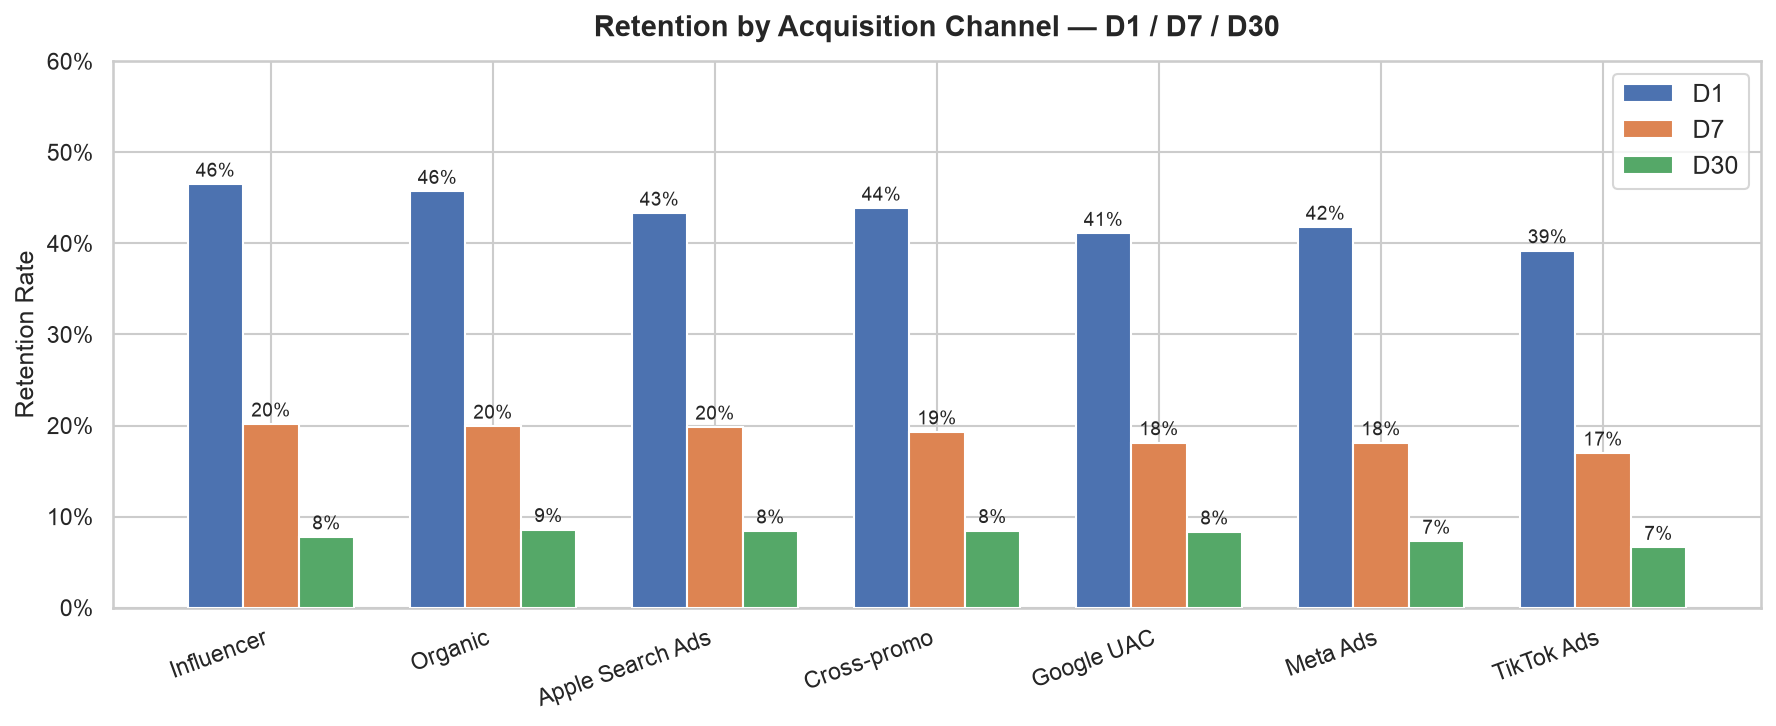

Chart saved ✓


In [9]:
cohort_channel = cohort_retention(players, 'acquisition_channel').sort_values('D7', ascending=False)
display(cohort_channel[['acquisition_channel','n_players','D1','D7','D30']]
        .style.format({'D1':'{:.1%}','D7':'{:.1%}','D30':'{:.1%}'})
        .bar(subset=['D7'], color='#4C72B0', vmin=0, vmax=0.30))

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(cohort_channel))
width = 0.25
for i, col in enumerate(['D1', 'D7', 'D30']):
    offset = (i - 1) * width
    vals   = cohort_channel[col].values
    ax.bar(x + offset, vals, width, label=col, color=PALETTE[i], zorder=3)
    for j, v in enumerate(vals):
        ax.text(x[j]+offset, v+0.004, f'{v:.0%}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(cohort_channel['acquisition_channel'], rotation=20, ha='right', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel('Retention Rate', fontsize=12)
ax.set_title('Retention by Acquisition Channel — D1 / D7 / D30', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 0.60)
plt.tight_layout()
plt.savefig(OUT_DIR / '01_retention_by_channel.png', dpi=150)
plt.show()
print('Chart saved ✓')

## 9. Retention by Platform

,platform,n_players,D1,D7,D30
0,Android,15734,42.0%,18.4%,7.6%
1,iOS,14266,43.9%,19.2%,8.4%


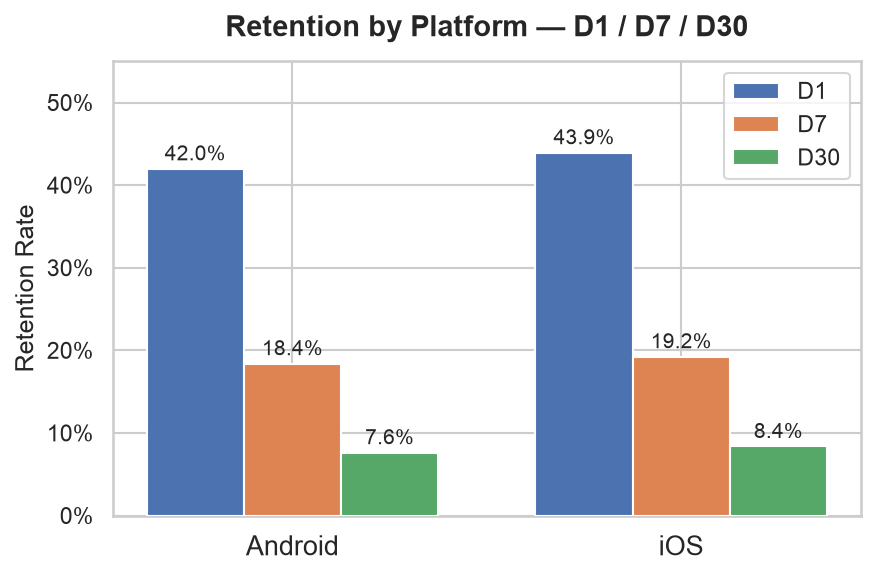

Chart saved ✓


In [10]:
cohort_platform = cohort_retention(players, 'platform')
display(cohort_platform[['platform','n_players','D1','D7','D30']]
        .style.format({'D1':'{:.1%}','D7':'{:.1%}','D30':'{:.1%}'}))

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(cohort_platform))
for i, col in enumerate(['D1', 'D7', 'D30']):
    offset = (i - 1) * 0.25
    vals   = cohort_platform[col].values
    ax.bar(x + offset, vals, 0.25, label=col, color=PALETTE[i], zorder=3)
    for j, v in enumerate(vals):
        ax.text(x[j]+offset, v+0.005, f'{v:.1%}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(cohort_platform['platform'], fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel('Retention Rate', fontsize=12)
ax.set_title('Retention by Platform — D1 / D7 / D30', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.savefig(OUT_DIR / '01_retention_by_platform.png', dpi=150)
plt.show()
print('Chart saved ✓')

## 10. Retention Heatmap — Cohort Week × Day

The standard way game studios visualise cohort health at a glance:  
each row is an install-week cohort; columns are D1, D7, D30.

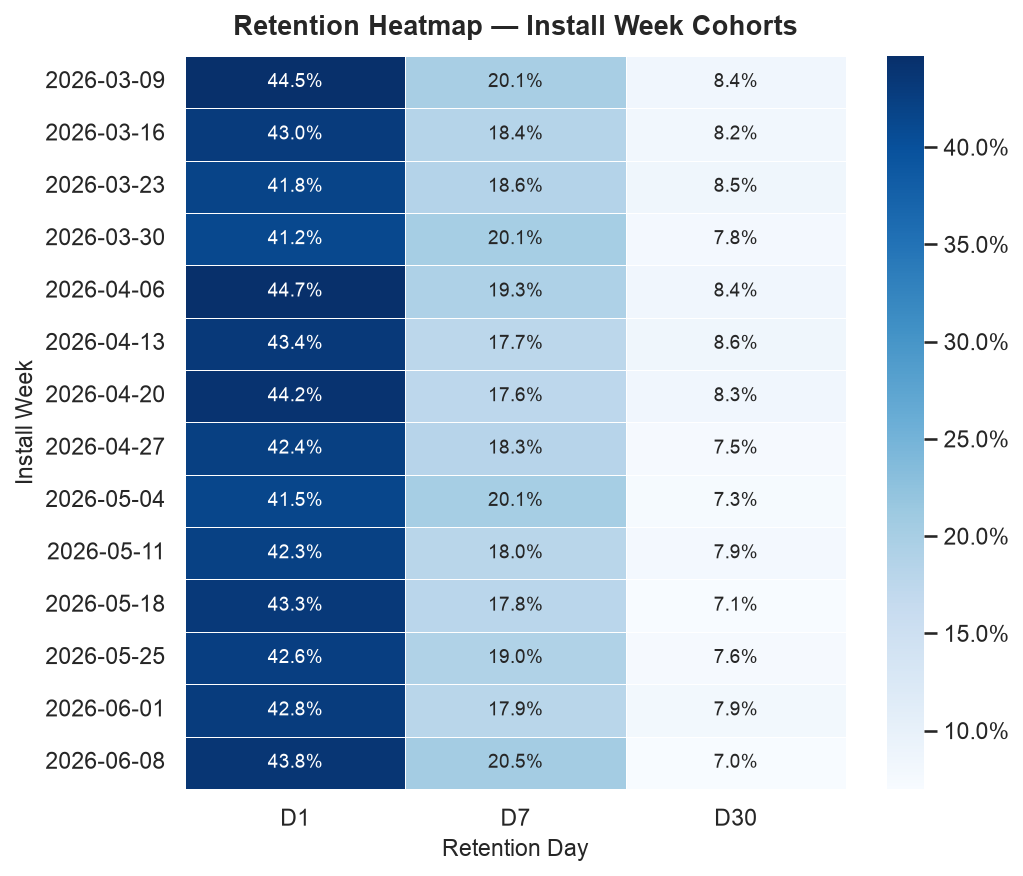

Chart saved ✓


In [11]:
heatmap_data = cohort_week.set_index('install_week')[['D1','D7','D30']].dropna()
heatmap_data.index = heatmap_data.index.strftime('%Y-%m-%d')

fig, ax = plt.subplots(figsize=(7, max(6, len(heatmap_data) * 0.35)))
sns.heatmap(
    heatmap_data, annot=True, fmt='.1%', cmap='Blues',
    linewidths=0.4, ax=ax, annot_kws={'size': 9},
    cbar_kws={'format': mtick.PercentFormatter(xmax=1)}
)
ax.set_title('Retention Heatmap — Install Week Cohorts', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Retention Day', fontsize=11)
ax.set_ylabel('Install Week', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / '01_retention_heatmap.png', dpi=150)
plt.show()
print('Chart saved ✓')

## 11. Export Results

In [12]:
overview.to_csv(OUT_DIR / '01_retention_overall.csv',       index=False)
cohort_week.to_csv(OUT_DIR / '01_retention_by_week.csv',    index=False)
cohort_channel.to_csv(OUT_DIR / '01_retention_by_channel.csv', index=False)
cohort_platform.to_csv(OUT_DIR / '01_retention_by_platform.csv', index=False)

print('All CSVs exported to:', OUT_DIR)
for f in sorted(OUT_DIR.glob('01_*.csv')):
    print(' ', f.name)

All CSVs exported to: /Users/ebimol/GamesAnalyticsProject/outputs
  01_retention_by_channel.csv
  01_retention_by_platform.csv
  01_retention_by_week.csv
  01_retention_overall.csv


## 12. Key Findings & Recommendations

| Metric | Value | Benchmark | Status |
|--------|-------|-----------|--------|
| D1 Retention | ~42.9% | 35–45% | ✅ Within benchmark |
| D7 Retention | ~18.8% | 15–20% | ✅ Within benchmark |
| D30 Retention | ~8.0% | 5–8% | ✅ At upper bound |

### Channel Insights
- **Organic and Influencer** channels produce the stickiest users (D7 ~20%) — these players likely  
  have higher pre-install intent.
- **TikTok Ads** shows the weakest D7 (~17%) and D30 (~6.6%) retention across all channels.  
  Recommend assessing LTV-adjusted ROAS before scaling spend (analysed in depth in Notebook 05).
- **Apple Search Ads** and **Cross-promo** sit mid-table and merit further LTV analysis.

### Platform Insights
- iOS users retain ~1–2pp better than Android at every horizon, consistent with iOS's  
  historically higher-intent user base in mobile gaming.

### Action for the Game Team
- Prioritise budget toward Organic amplification (SEO/ASO, community) and Influencer partnerships.
- Flag TikTok Ads for a creative refresh and CPI-vs-LTV audit before Q4 UA scaling.
- Investigate any cohort weeks with D1 dips below 38% in the heatmap for product-side regression.

---
*Next: Notebook 02 — Funnel & Drop-off Analysis*